<a href="https://colab.research.google.com/github/gitaprangesti/ml_apps/blob/main/Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Regresi**
**Algoritma** : Linear Regression, Random Forest Regressor, Gradient Boosting Regressor
**Data** : Dataset kaggle student performance dan data sekunder (30 reponden)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Library berhasil diimport')

Library berhasil diimport


In [ ]:
df_kaggle = pd.read_csv('Student_Performance.csv')
df_survey = pd.read_csv('data_sekunder.csv', sep=';')

print(f'Kaggle  : {df_kaggle.shape[0]} baris, {df_kaggle.shape[1]} kolom')
print(f'Kuesioner: {df_survey.shape[0]} baris, {df_survey.shape[1]} kolom')
print()
print('Kolom Kaggle:', df_kaggle.columns.tolist())
print()
print('Kolom Kuesioner:', df_survey.columns.tolist())

Kaggle  : 10000 baris, 6 kolom
Kuesioner: 30 baris, 6 kolom

Kolom Kaggle: ['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index']

Kolom Kuesioner: ['Berapa jam rata-rata Anda tidur dalam sehari selama masa perkuliahan? (Contoh: 7)', 'Berapa jam yang Anda habiskan untuk belajar di luar jam kuliah dalam satu hari? (Contoh: 2)', 'Berapa rata-rata nilai ujian atau tugas Anda pada semester sebelumnya atau tes besar terakhir? ', 'Apakah Anda aktif mengikuti organisasi (Hima, UKM), kepanitiaan, atau komunitas di luar jadwal akademik rutin?', 'Dalam satu bulan terakhir, berapa banyak set soal latihan, simulasi ujian, atau try-out yang Anda kerjakan secara mandiri?', 'Berapa IPK Anda saat ini?']


In [ ]:
print('SUMBER DATA')
print('1. Data Sekunder (Kaggle)')
print('   URL  : https://www.kaggle.com/datasets/nikhil7280/student-performance-multiple-linear-regression')
print('   Baris: 10.000 (akan disampling 500)')
print('   Peran: Training dan testing utama')
print()
print('2. Data Primer (Kuesioner)')
print('   Sumber: Google Form, mahasiswa lokal')
print('   Baris : 30 responden')
print('   Peran : Independent test set (validasi nyata)')
print()
print('VARIABEL')
print('Input (X):')
print('  Hours Studied                    - Jam belajar per hari')
print('  Previous Scores                  - Nilai ujian sebelumnya (0-100)')
print('  Extracurricular Activities       - Aktif ekskul (Yes/No)')
print('  Sleep Hours                      - Jam tidur per hari')
print('  Sample Question Papers Practiced - Jumlah soal latihan')
print()
print('Target (y):')
print('  Performance Index                - Indeks performa akademik (10-100)')

SUMBER DATA
1. Data Sekunder (Kaggle)
   URL  : https://www.kaggle.com/datasets/nikhil7280/student-performance-multiple-linear-regression
   Baris: 10.000 (akan disampling 500)
   Peran: Training dan testing utama

2. Data Primer (Kuesioner)
   Sumber: Google Form, mahasiswa lokal
   Baris : 30 responden
   Peran : Independent test set (validasi nyata)

VARIABEL
Input (X):
  Hours Studied                    - Jam belajar per hari
  Previous Scores                  - Nilai ujian sebelumnya (0-100)
  Extracurricular Activities       - Aktif ekskul (Yes/No)
  Sleep Hours                      - Jam tidur per hari
  Sample Question Papers Practiced - Jumlah soal latihan

Target (y):
  Performance Index                - Indeks performa akademik (10-100)


In [ ]:
print('Statistik Deskriptif - Kaggle:')
display(df_kaggle.describe().round(2))

print('Statistik Deskriptif - Kuesioner:')
display(df_survey.describe().round(2))

Statistik Deskriptif - Kaggle:


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.00,10000.00,10000.00,10000.00,10000.00
mean,4.99,69.45,6.53,4.58,55.22
std,2.59,17.34,1.70,2.87,19.21
min,1.00,40.00,4.00,0.00,10.00
25%,3.00,54.00,5.00,2.00,40.00
50%,5.00,69.00,7.00,5.00,55.00
75%,7.00,85.00,8.00,7.00,71.00
max,9.00,99.00,9.00,9.00,100.00


Statistik Deskriptif - Kuesioner:


,Berapa jam rata-rata Anda tidur dalam sehari selama masa perkuliahan? (Contoh: 7),Berapa rata-rata nilai ujian atau tugas Anda pada semester sebelumnya atau tes besar terakhir?,"Dalam satu bulan terakhir, berapa banyak set soal latihan, simulasi ujian, atau try-out yang Anda kerjakan secara mandiri?"
count,30.00,30.00,30.00
mean,5.43,82.47,1.20
std,1.38,5.06,2.14
min,2.00,70.00,0.00
25%,5.00,80.00,0.00
50%,5.50,80.00,0.00
75%,6.00,85.00,1.75
max,8.00,90.00,9.00


In [ ]:
# Rename kolom kuesioner agar sama dengan Kaggle
df_survey.columns = [
    'Sleep Hours',
    'Hours Studied',
    'Previous Scores',
    'Extracurricular Activities',
    'Sample Question Papers Practiced',
    'Performance Index'
]

# Konversi IPK (0-4) ke Performance Index (10-100)
# Kaggle range: 10-100, IPK range: 0-4
# Rumus: PI = IPK * 25
df_survey['Performance Index'] = df_survey['Performance Index'].astype(str).str.replace(',', '.').astype(float)
df_survey['Performance Index'] = (df_survey['Performance Index'] * 25).round(1)

# Samakan encoding: Ya/Tidak -> Yes/No
df_survey['Extracurricular Activities'] = df_survey['Extracurricular Activities'].map({'Ya': 'Yes', 'Tidak': 'No'})

# Samakan urutan kolom dengan Kaggle
df_survey = df_survey[['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
                        'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index']]

print('Kuesioner setelah diseragamkan:')
display(df_survey.head())
print()
print('Tipe data kuesioner:')
print(df_survey.dtypes)

Kuesioner setelah diseragamkan:


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,2,86,Yes,4,5,96.2
1,2,80,No,5,1,83.8
2,3,80,No,6,1,84.5
3,1,80,No,7,0,85.0
4,1,85,No,6,0,87.5



Tipe data kuesioner:
Hours Studied                        object
Previous Scores                       int64
Extracurricular Activities           object
Sleep Hours                           int64
Sample Question Papers Practiced      int64
Performance Index                   float64
dtype: object


In [ ]:
# Sampling 500 baris dari 10.000 agar efisien
np.random.seed(42)
df_kaggle_sample = df_kaggle.sample(500, random_state=42).reset_index(drop=True)

# Tandai sumber
df_kaggle_sample['Sumber'] = 'Kaggle'
df_survey['Sumber'] = 'Kuesioner'

# Gabung
df_combined = pd.concat([df_kaggle_sample, df_survey], ignore_index=True)

print(f'Total data gabungan : {df_combined.shape[0]} baris')
print(f'  Kaggle            : {(df_combined["Sumber"]=="Kaggle").sum()} baris')
print(f'  Kuesioner         : {(df_combined["Sumber"]=="Kuesioner").sum()} baris')
display(df_combined.head())

Total data gabungan : 530 baris
  Kaggle            : 500 baris
  Kuesioner         : 30 baris


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index,Sumber
0,5,69,No,8,2,51.0,Kaggle
1,2,46,Yes,4,8,20.0,Kaggle
2,7,56,Yes,7,5,46.0,Kaggle
3,6,42,Yes,8,5,28.0,Kaggle
4,7,53,No,4,6,41.0,Kaggle


In [ ]:
print('Missing values per kolom:')
print(df_combined.isnull().sum())

# Isi missing value numerik dengan median, kategorikal dengan modus
for col in df_combined.columns:
    if col == 'Sumber':
        continue
    if df_combined[col].dtype == 'object':
        df_combined[col].fillna(df_combined[col].mode()[0], inplace=True)
    else:
        df_combined[col].fillna(df_combined[col].median(), inplace=True)

print()
print('Missing values setelah ditangani:')
print(df_combined.isnull().sum())

Missing values per kolom:
Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
Sumber                              0
dtype: int64

Missing values setelah ditangani:
Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
Sumber                              0
dtype: int64


In [ ]:
num_cols = ['Hours Studied', 'Previous Scores', 'Sleep Hours',
            'Sample Question Papers Practiced', 'Performance Index']

for col in num_cols:
    df_combined[col] = pd.to_numeric(df_combined[col], errors='coerce')
    df_combined[col].fillna(df_combined[col].median(), inplace=True)

print('Tipe data setelah konversi:')
print(df_combined[num_cols].dtypes)
print()
print('Sample data numerik:')
display(df_combined[num_cols].head())

Tipe data setelah konversi:
Hours Studied                       float64
Previous Scores                       int64
Sleep Hours                           int64
Sample Question Papers Practiced      int64
Performance Index                   float64
dtype: object

Sample data numerik:


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,5.0,69,8,2,51.0
1,2.0,46,4,8,20.0
2,7.0,56,7,5,46.0
3,6.0,42,8,5,28.0
4,7.0,53,4,6,41.0


In [ ]:
df_clean = df_combined.copy()

print('Deteksi Outlier (Metode IQR):')
for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    jumlah = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)].shape[0]
    print(f'  {col}: {jumlah} outlier (batas {lower:.2f} - {upper:.2f})')
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

print()
print('Outlier ditangani dengan clipping')
print(f'Ukuran data: {df_clean.shape}')

Deteksi Outlier (Metode IQR):
  Hours Studied: 0 outlier (batas -3.00 - 13.00)
  Previous Scores: 0 outlier (batas 10.50 - 126.50)
  Sleep Hours: 0 outlier (batas 0.50 - 12.50)
  Sample Question Papers Practiced: 0 outlier (batas -5.50 - 14.50)
  Performance Index: 0 outlier (batas -12.00 - 124.00)

Outlier ditangani dengan clipping
Ukuran data: (530, 7)


In [ ]:
# Encoding Yes/No -> 1/0
le = LabelEncoder()
df_clean['Extracurricular Activities'] = le.fit_transform(df_clean['Extracurricular Activities'])

print('Encoding Extracurricular: Yes=1, No=0')
print(df_clean['Extracurricular Activities'].value_counts())

# Pisah fitur dan target
feature_cols = ['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
                'Sleep Hours', 'Sample Question Papers Practiced']

X = df_clean[feature_cols].values
y = df_clean['Performance Index'].values
sumber = df_clean['Sumber'].values

# Standarisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print()
print(f'Total data siap: {len(X)} sampel, {X.shape[1]} fitur')

Encoding Extracurricular: Yes=1, No=0
Extracurricular Activities
0    269
1    261
Name: count, dtype: int64

Total data siap: 530 sampel, 5 fitur


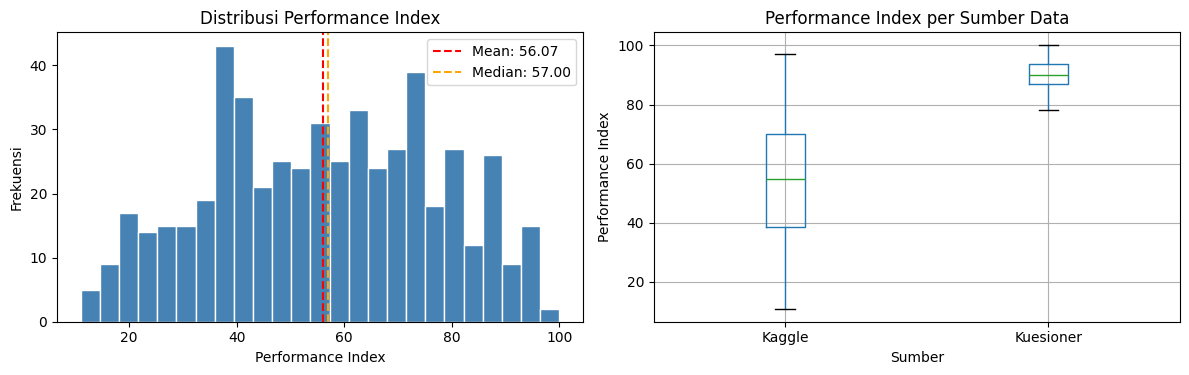

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_clean['Performance Index'], bins=25, color='steelblue', edgecolor='white')
axes[0].axvline(df_clean['Performance Index'].mean(), color='red', linestyle='--',
                label=f"Mean: {df_clean['Performance Index'].mean():.2f}")
axes[0].axvline(df_clean['Performance Index'].median(), color='orange', linestyle='--',
                label=f"Median: {df_clean['Performance Index'].median():.2f}")
axes[0].set_title('Distribusi Performance Index')
axes[0].set_xlabel('Performance Index')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

df_clean.boxplot(column='Performance Index', by='Sumber', ax=axes[1])
axes[1].set_title('Performance Index per Sumber Data')
axes[1].set_xlabel('Sumber')
axes[1].set_ylabel('Performance Index')
plt.suptitle('')
plt.tight_layout()
plt.savefig('eda_distribusi_target.png', dpi=150, bbox_inches='tight')
plt.show()

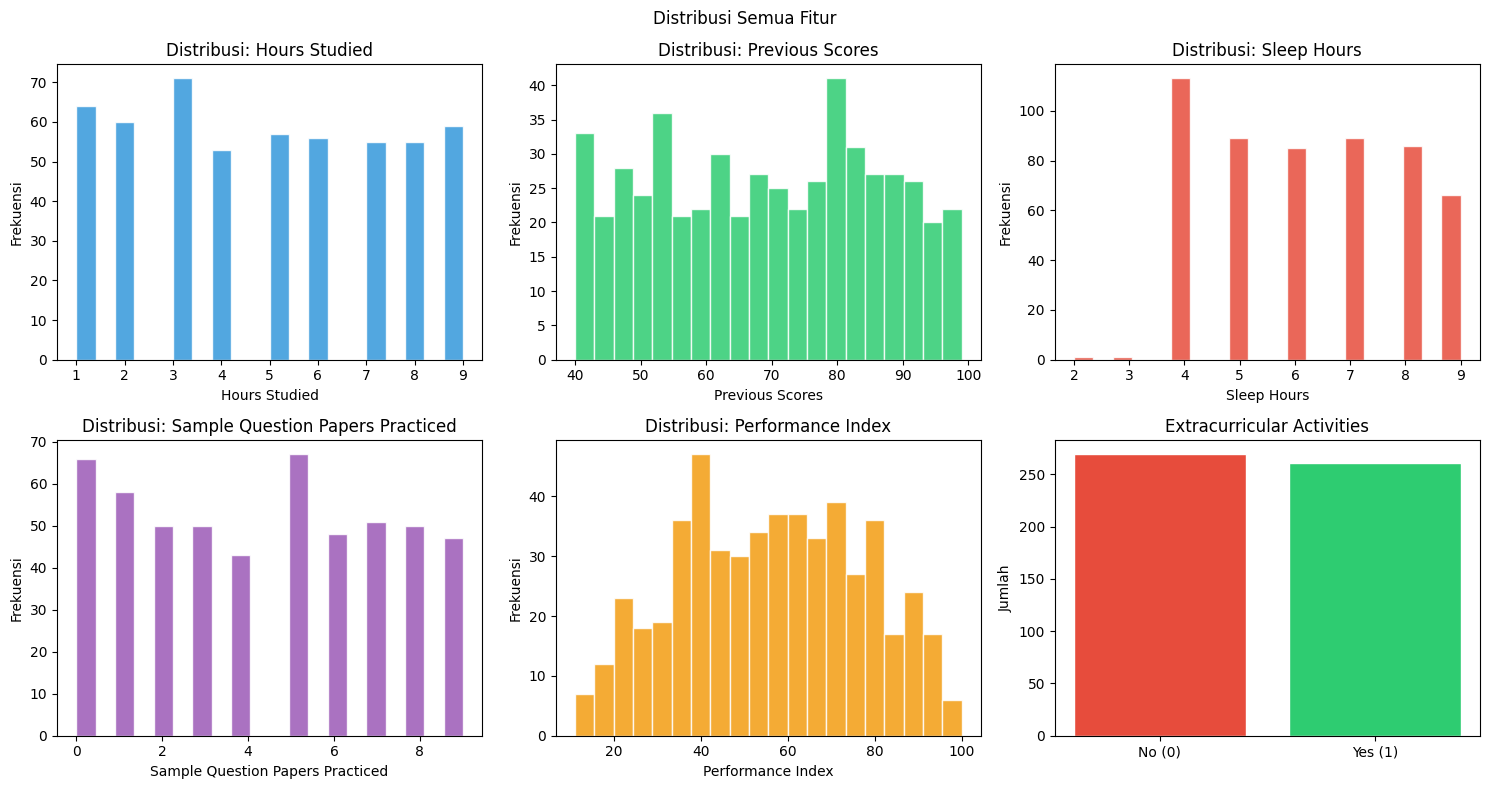

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

plot_cols = num_cols
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']

for i, (col, color) in enumerate(zip(plot_cols, colors)):
    axes[i].hist(df_clean[col], bins=20, color=color, edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribusi: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

ext_counts = df_clean['Extracurricular Activities'].value_counts()
axes[5].bar(['No (0)', 'Yes (1)'], [ext_counts.get(0, 0), ext_counts.get(1, 0)],
            color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[5].set_title('Extracurricular Activities')
axes[5].set_ylabel('Jumlah')

plt.suptitle('Distribusi Semua Fitur')
plt.tight_layout()
plt.savefig('eda_distribusi_fitur.png', dpi=150, bbox_inches='tight')
plt.show()

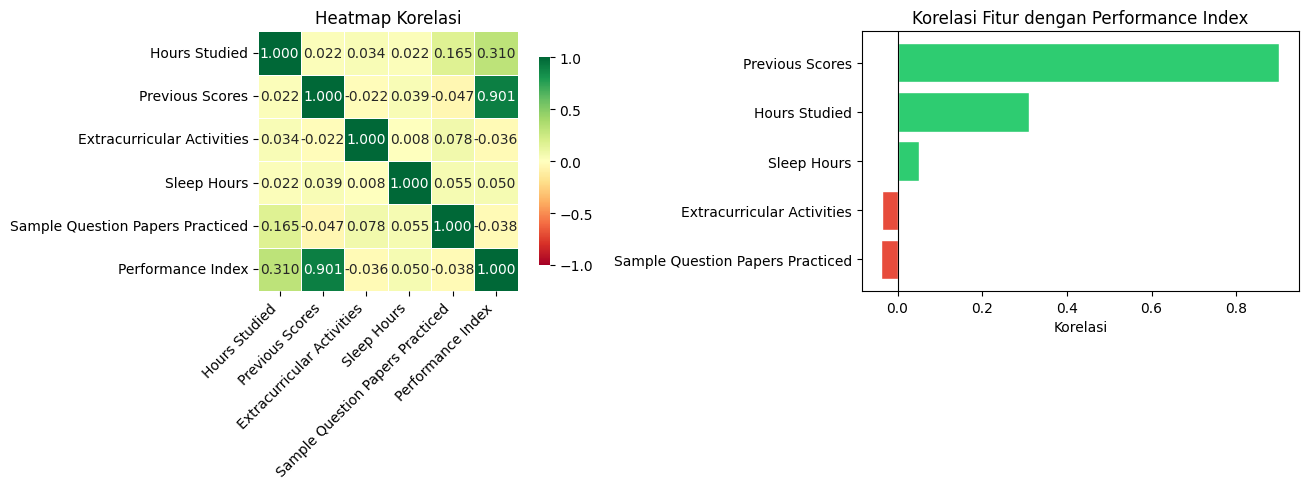

Nilai korelasi dengan Performance Index:
Previous Scores                     0.901
Hours Studied                       0.310
Sleep Hours                         0.050
Extracurricular Activities         -0.036
Sample Question Papers Practiced   -0.038
Name: Performance Index, dtype: float64


In [ ]:
corr_cols = feature_cols + ['Performance Index']
corr_matrix = df_clean[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    vmin=-1, vmax=1, center=0,   # penting supaya warna konsisten
    square=True,
    linewidths=0.5,
    ax=axes[0],
    cbar_kws={"shrink": .8}
)

axes[0].set_title('Heatmap Korelasi')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

corr_target = corr_matrix['Performance Index'].drop('Performance Index').sort_values()

colors_bar = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_target]

axes[1].barh(
    corr_target.index,
    corr_target.values,
    color=colors_bar,
    edgecolor='white'
)

axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Korelasi Fitur dengan Performance Index')
axes[1].set_xlabel('Korelasi')

plt.tight_layout()
plt.savefig('eda_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

print('Nilai korelasi dengan Performance Index:')
print(corr_target.sort_values(ascending=False).round(3))

In [ ]:
# Pisah berdasarkan sumber
mask_kaggle = sumber == 'Kaggle'
mask_survey = sumber == 'Kuesioner'

X_kaggle = X_scaled[mask_kaggle]
y_kaggle = y[mask_kaggle]

X_survey = X_scaled[mask_survey]
y_survey = y[mask_survey]

# 3 variasi split dari data Kaggle
splits = {}
for test_size, label in [(0.30, '70:30'), (0.20, '80:20'), (0.10, '90:10')]:
    X_tr, X_te, y_tr, y_te = train_test_split(X_kaggle, y_kaggle,
                                               test_size=test_size, random_state=42)
    splits[label] = (X_tr, X_te, y_tr, y_te)
    print(f'Split {label} -> Train: {len(X_tr)}, Test: {len(X_te)}')

print(f'Independent test (kuesioner): {len(X_survey)} sampel')

Split 70:30 -> Train: 350, Test: 150
Split 80:20 -> Train: 400, Test: 100
Split 90:10 -> Train: 450, Test: 50
Independent test (kuesioner): 30 sampel


In [ ]:
def evaluasi(nama, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)
    return {
        'Model'      : nama,
        'MAE'        : round(mae, 4),
        'MSE'        : round(mse, 4),
        'RMSE'       : round(rmse, 4),
        'R2'         : round(r2, 4),
        'Akurasi_%'  : round(r2 * 100, 2),
        'y_pred'     : y_pred,
        'object'     : model
    }

print('Fungsi evaluasi siap')

Fungsi evaluasi siap


In [ ]:
print('LINEAR REGRESSION - GridSearchCV')

X_tr, X_te, y_tr, y_te = splits['80:20']

gs_lr = GridSearchCV(LinearRegression(),
                     {'fit_intercept': [True, False]},
                     cv=5, scoring='r2')
gs_lr.fit(X_tr, y_tr)
print(f'Best params: {gs_lr.best_params_}')
print(f'Best CV R2 : {gs_lr.best_score_:.4f}')

res_lr = {}
for label, (X_tr_s, X_te_s, y_tr_s, y_te_s) in splits.items():
    model = LinearRegression(**gs_lr.best_params_)
    res_lr[label] = evaluasi('Linear Regression', model, X_tr_s, X_te_s, y_tr_s, y_te_s)
    r = res_lr[label]
    print(f'  Split {label}: MAE={r["MAE"]} | RMSE={r["RMSE"]} | R2={r["R2"]} ({r["Akurasi_%"]}%)')

LINEAR REGRESSION - GridSearchCV
Best params: {'fit_intercept': True}
Best CV R2 : 0.9895
  Split 70:30: MAE=1.4816 | RMSE=1.9198 | R2=0.9911 (99.11%)
  Split 80:20: MAE=1.5822 | RMSE=2.0383 | R2=0.9901 (99.01%)
  Split 90:10: MAE=1.6423 | RMSE=2.12 | R2=0.9883 (98.83%)


In [ ]:
print('RANDOM FOREST - GridSearchCV')

X_tr, X_te, y_tr, y_te = splits['80:20']

gs_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    {'n_estimators': [100, 200, 300],
     'max_depth'   : [5, 10, None],
     'min_samples_split': [2, 5]},
    cv=5, scoring='r2', n_jobs=-1)
gs_rf.fit(X_tr, y_tr)
print(f'Best params: {gs_rf.best_params_}')
print(f'Best CV R2 : {gs_rf.best_score_:.4f}')

res_rf = {}
for label, (X_tr_s, X_te_s, y_tr_s, y_te_s) in splits.items():
    model = RandomForestRegressor(**gs_rf.best_params_, random_state=42)
    res_rf[label] = evaluasi('Random Forest', model, X_tr_s, X_te_s, y_tr_s, y_te_s)
    r = res_rf[label]
    print(f'  Split {label}: MAE={r["MAE"]} | RMSE={r["RMSE"]} | R2={r["R2"]} ({r["Akurasi_%"]}%)')

RANDOM FOREST - GridSearchCV
Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R2 : 0.9818
  Split 70:30: MAE=2.1663 | RMSE=2.7768 | R2=0.9814 (98.14%)
  Split 80:20: MAE=2.1444 | RMSE=2.7075 | R2=0.9826 (98.26%)
  Split 90:10: MAE=2.0854 | RMSE=2.7401 | R2=0.9804 (98.04%)


In [ ]:
print('GRADIENT BOOSTING - GridSearchCV')

X_tr, X_te, y_tr, y_te = splits['80:20']

gs_gb = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    {'n_estimators' : [100, 200, 300],
     'learning_rate': [0.05, 0.1, 0.2],
     'max_depth'    : [3, 5, 7],
     'subsample'    : [0.8, 1.0]},
    cv=5, scoring='r2', n_jobs=-1)
gs_gb.fit(X_tr, y_tr)
print(f'Best params: {gs_gb.best_params_}')
print(f'Best CV R2 : {gs_gb.best_score_:.4f}')

res_gb = {}
for label, (X_tr_s, X_te_s, y_tr_s, y_te_s) in splits.items():
    model = GradientBoostingRegressor(**gs_gb.best_params_, random_state=42)
    res_gb[label] = evaluasi('Gradient Boosting', model, X_tr_s, X_te_s, y_tr_s, y_te_s)
    r = res_gb[label]
    print(f'  Split {label}: MAE={r["MAE"]} | RMSE={r["RMSE"]} | R2={r["R2"]} ({r["Akurasi_%"]}%)')

GRADIENT BOOSTING - GridSearchCV
Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Best CV R2 : 0.9863
  Split 70:30: MAE=1.7695 | RMSE=2.2672 | R2=0.9876 (98.76%)
  Split 80:20: MAE=1.8241 | RMSE=2.2649 | R2=0.9878 (98.78%)
  Split 90:10: MAE=1.8954 | RMSE=2.4476 | R2=0.9844 (98.44%)


In [ ]:
rows = []
for split in ['70:30', '80:20', '90:10']:
    for nama, results in [('Linear Regression', res_lr),
                           ('Random Forest', res_rf),
                           ('Gradient Boosting', res_gb)]:
        r = results[split]
        rows.append({
            'Algoritma'  : nama,
            'Split'      : split,
            'MAE'        : r['MAE'],
            'MSE'        : r['MSE'],
            'RMSE'       : r['RMSE'],
            'R2'         : r['R2'],
            'Akurasi_%'  : r['Akurasi_%']
        })

df_comparison = pd.DataFrame(rows)
print('TABEL PERBANDINGAN SEMUA MODEL')
display(df_comparison)

TABEL PERBANDINGAN SEMUA MODEL


,Algoritma,Split,MAE,MSE,RMSE,R2,Akurasi_%
0,Linear Regression,70:30,1.4816,3.6858,1.9198,0.9911,99.11
1,Random Forest,70:30,2.1663,7.7104,2.7768,0.9814,98.14
2,Gradient Boosting,70:30,1.7695,5.1402,2.2672,0.9876,98.76
3,Linear Regression,80:20,1.5822,4.1547,2.0383,0.9901,99.01
4,Random Forest,80:20,2.1444,7.3308,2.7075,0.9826,98.26
5,Gradient Boosting,80:20,1.8241,5.1299,2.2649,0.9878,98.78
6,Linear Regression,90:10,1.6423,4.4942,2.1200,0.9883,98.83
7,Random Forest,90:10,2.0854,7.5079,2.7401,0.9804,98.04
8,Gradient Boosting,90:10,1.8954,5.9910,2.4476,0.9844,98.44


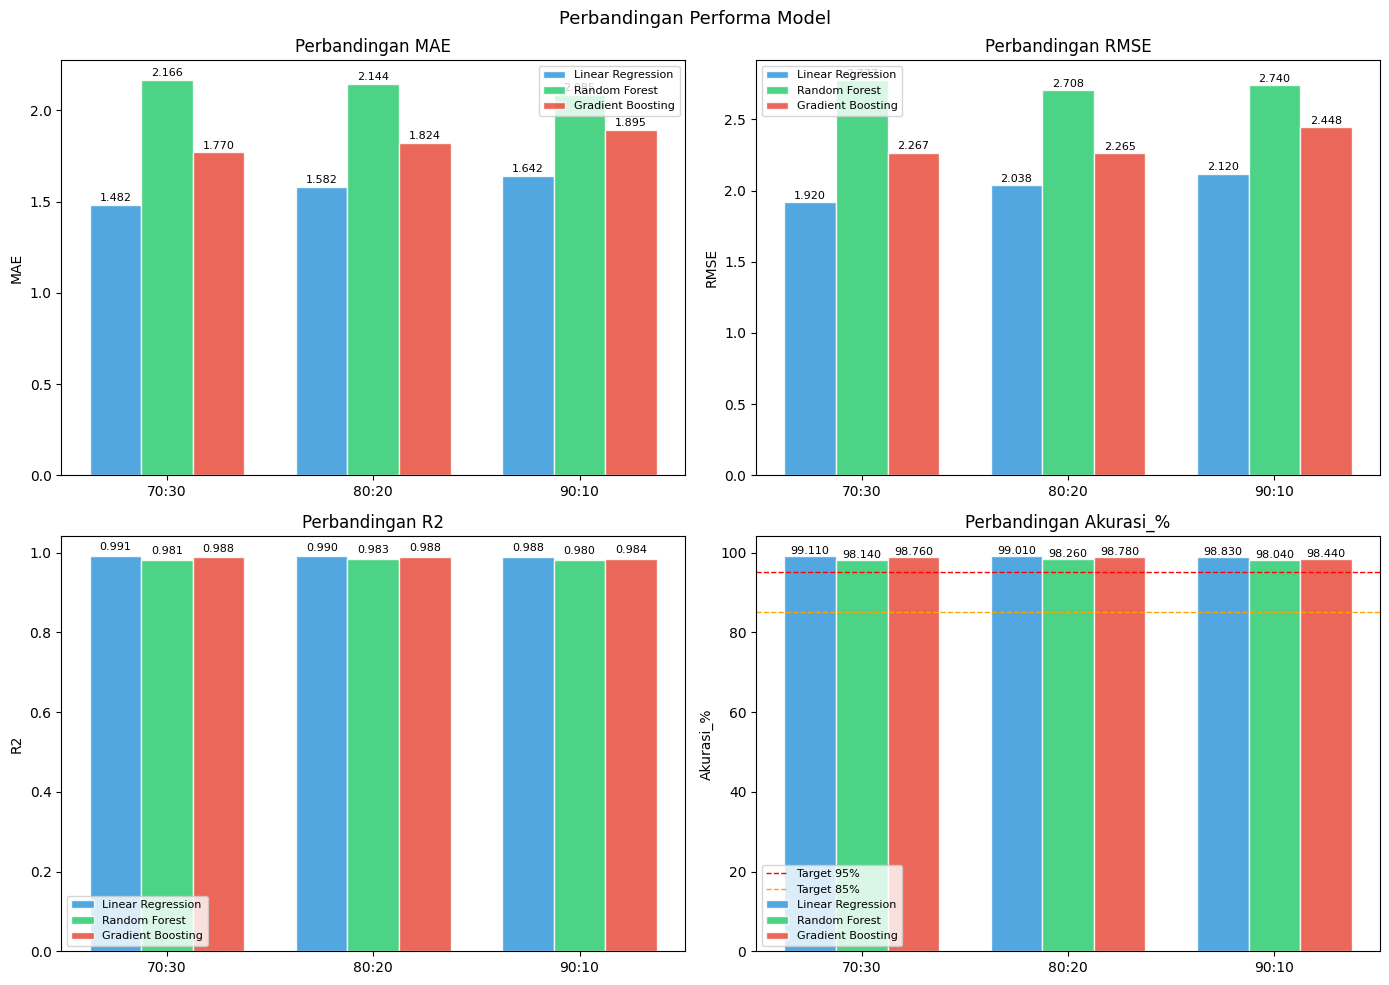

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['MAE', 'RMSE', 'R2', 'Akurasi_%']
warna = {'Linear Regression': '#3498db', 'Random Forest': '#2ecc71', 'Gradient Boosting': '#e74c3c'}
x = np.arange(3)
w = 0.25

for ax, metric in zip(axes.flatten(), metrics):
    for i, (algo, color) in enumerate(warna.items()):
        vals = [df_comparison[(df_comparison['Algoritma']==algo) &
                              (df_comparison['Split']==s)][metric].values[0]
                for s in ['70:30', '80:20', '90:10']]
        bars = ax.bar(x + i*w, vals, w, label=algo, color=color, alpha=0.85, edgecolor='white')
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x + w)
    ax.set_xticklabels(['70:30', '80:20', '90:10'])
    ax.set_title(f'Perbandingan {metric}')
    ax.set_ylabel(metric)
    ax.legend(fontsize=8)
    if metric == 'Akurasi_%':
        ax.axhline(95, color='red', linestyle='--', linewidth=1, label='Target 95%')
        ax.axhline(85, color='orange', linestyle='--', linewidth=1, label='Target 85%')
        ax.legend(fontsize=8)

plt.suptitle('Perbandingan Performa Model', fontsize=13)
plt.tight_layout()
plt.savefig('grafik_perbandingan.png', dpi=150, bbox_inches='tight')
plt.show()

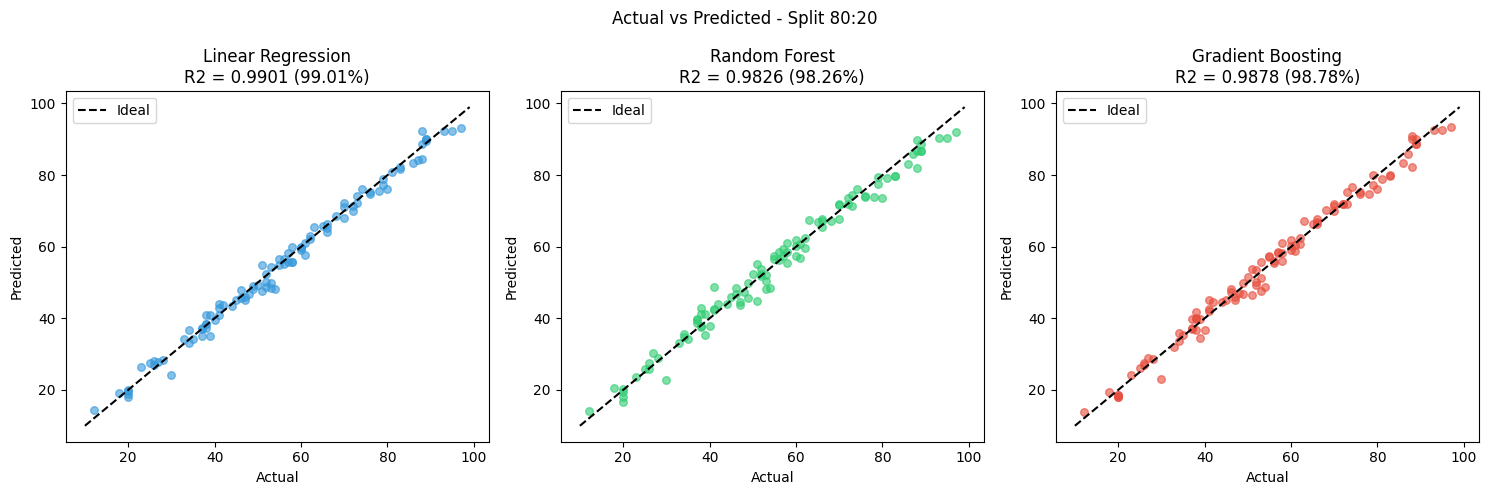

In [ ]:
X_tr, X_te, y_tr, y_te = splits['80:20']

# Re-train dengan parameter terbaik
m_lr = LinearRegression(**gs_lr.best_params_)
m_lr.fit(X_tr, y_tr)

m_rf = RandomForestRegressor(**gs_rf.best_params_, random_state=42)
m_rf.fit(X_tr, y_tr)

m_gb = GradientBoostingRegressor(**gs_gb.best_params_, random_state=42)
m_gb.fit(X_tr, y_tr)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (nama, model, color) in zip(axes, [
        ('Linear Regression', m_lr, '#3498db'),
        ('Random Forest',     m_rf, '#2ecc71'),
        ('Gradient Boosting', m_gb, '#e74c3c')]):
    y_pred = model.predict(X_te)
    r2 = r2_score(y_te, y_pred)
    ax.scatter(y_te, y_pred, color=color, alpha=0.6, s=30)
    mn, mx = min(y_te.min(), y_pred.min())-2, max(y_te.max(), y_pred.max())+2
    ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1.5, label='Ideal')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{nama}\nR2 = {r2:.4f} ({r2*100:.2f}%)')
    ax.legend()

plt.suptitle('Actual vs Predicted - Split 80:20')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print('EVALUASI PADA DATA KUESIONER (30 RESPONDEN)')
print('Model dilatih dengan data Kaggle, diuji pada data nyata lokal')
print()

survey_rows = []
for nama, model in [('Linear Regression', m_lr),
                     ('Random Forest',     m_rf),
                     ('Gradient Boosting', m_gb)]:
    y_pred = model.predict(X_survey)
    mae  = mean_absolute_error(y_survey, y_pred)
    mse  = mean_squared_error(y_survey, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_survey, y_pred)
    survey_rows.append({
        'Algoritma': nama,
        'MAE' : round(mae, 4),
        'MSE' : round(mse, 4),
        'RMSE': round(rmse, 4),
        'R2'  : round(r2, 4),
        'Akurasi_%': round(r2*100, 2)
    })
    print(f'{nama}: MAE={mae:.4f} | RMSE={rmse:.4f} | R2={r2:.4f} ({r2*100:.2f}%)')

display(pd.DataFrame(survey_rows))

EVALUASI PADA DATA KUESIONER (30 RESPONDEN)
Model dilatih dengan data Kaggle, diuji pada data nyata lokal

Linear Regression: MAE=29.5038 | RMSE=30.2226 | R2=-32.9491 (-3294.91%)
Random Forest: MAE=27.8049 | RMSE=28.3848 | R2=-28.9458 (-2894.58%)
Gradient Boosting: MAE=29.3920 | RMSE=30.1266 | R2=-32.7337 (-3273.37%)


,Algoritma,MAE,MSE,RMSE,R2,Akurasi_%
0,Linear Regression,29.5038,913.4056,30.2226,-32.9491,-3294.91
1,Random Forest,27.8049,805.6974,28.3848,-28.9458,-2894.58
2,Gradient Boosting,29.3920,907.6105,30.1266,-32.7337,-3273.37


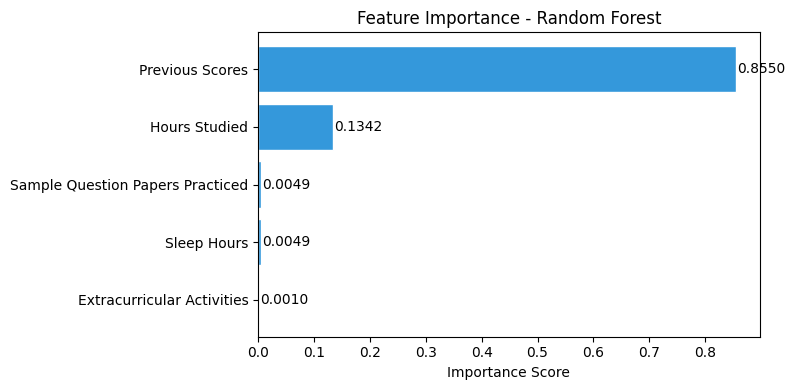

In [ ]:
importances = m_rf.feature_importances_
fi_df = pd.DataFrame({'Fitur': feature_cols, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(fi_df['Fitur'], fi_df['Importance'], color='#3498db', edgecolor='white')
for i, v in enumerate(fi_df['Importance']):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=10)
ax.set_xlabel('Importance Score')
ax.set_title('Feature Importance - Random Forest')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

X = df_clean[feature_cols]
y = df_clean['Performance Index']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
import pickle

with open('model_linear_regression.pkl', 'wb') as f:
    pickle.dump(model_lr, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model dan scaler berhasil disimpan")

Model dan scaler berhasil disimpan


In [ ]:
from google.colab import files

files.download('model_linear_regression.pkl')
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>